# S08 – Нейронные сети: основы (PyTorch)
## MLP-бейзлайн и борьба с переобучением: Dropout, BatchNorm, EarlyStopping

В этом ноутбуке **собираем первую нейросетевую модель** в PyTorch и разбираемм, что в ней за что отвечает.

**По итогу семинара необходимо уметь:**
- собрать MLP (полносвязную нейросеть);
- написать понятный цикл обучения (train, eval, `no_grad`, перенос на `device`);
- увидеть переобучение по кривым обучения и **уметь его уменьшать** с помощью:
  - `Dropout`,
  - `BatchNorm`,
  - `EarlyStopping`;
- на простом примере понять, что **активации и инициализация** реально влияют на обучение (скорость, стабильность).

> Примечание: ноутбук рассчитан на запуск в Colab или локально. Если GPU нет – всё тоже работает, просто медленнее.

## Импорты и общие настройки

Сразу сделаем две инженерные привычки:
1) фиксируем seed (воспроизводимость),
2) явно выбираем `device` (CPU/GPU).

In [1]:
# Базовые библиотеки
import os
import random
import numpy as np
import matplotlib.pyplot as plt

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

# Датасеты / трансформации
import torchvision
from torchvision import transforms

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

torch: 2.10.0
torchvision: 0.25.0


In [2]:
def set_seed(seed: int = 42) -> None:
    # Фиксируем seed для воспроизводимости (насколько это возможно).
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Более детерминированное поведение (может чуть замедлить).
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


## Вспомогательные функции (метрики и графики)

Мы будем смотреть минимум:
- `loss`,
- `accuracy`.

И будем строить кривые train/val.

In [3]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    # Accuracy для классификации: logits -> argmax -> сравнение с y_true.
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()


def plot_history(history: dict, title: str = "") -> None:
    # history ожидается вида:
    # {
    #   "train_loss": [...], "val_loss": [...],
    #   "train_acc": [...],  "val_acc": [...]
    # }
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title((title + " (loss)") if title else "loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure()
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title((title + " (accuracy)") if title else "accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

## Данные: Fashion-MNIST

Это простой датасет картинок одежды (10 классов).
Мы делаем MLP, поэтому:
- берём картинки 28×28,
- превращаем в вектор 784 (через `Flatten` внутри модели).

Дополнительно:
- нормализуем входы (это помогает стабилизировать обучение).

In [4]:
# Трансформации: ToTensor и Normalize
# FashionMNIST уже в [0,1] после ToTensor, но нормализация помогает обучению.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),  # mean/std для 1 канала
])

# Скачиваем датасет
train_full = torchvision.datasets.FashionMNIST(
    root="./data", train=True, download=True, transform=transform
)
test_ds = torchvision.datasets.FashionMNIST(
    root="./data", train=False, download=True, transform=transform
)

class_names = train_full.classes
print("classes:", class_names)
print("train size:", len(train_full))
print("test size:", len(test_ds))

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 204kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.79MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 14.8MB/s]

classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
train size: 60000
test size: 10000


### Разбиение train/val и DataLoader

Обучающую часть делим на:
- `train`,
- `val`.

Затем создаём `DataLoader`, который выдаёт батчи.


In [5]:
# Размер батча подстроим под наличие GPU
BATCH_SIZE = 256 if device.type == "cuda" else 64

# На Windows в Jupyter иногда бывают проблемы с multiprocessing в DataLoader.
# Поэтому автоматически ставим num_workers=0 на Windows, иначе 2.
NUM_WORKERS = 0 if os.name == "nt" else 2

# train/val split
val_ratio = 0.1
val_size = int(len(train_full) * val_ratio)
train_size = len(train_full) - val_size

gen = torch.Generator().manual_seed(42)
train_ds, val_ds = random_split(train_full, [train_size, val_size], generator=gen)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)

# Быстрый sanity-check
x_batch, y_batch = next(iter(train_loader))
print("x_batch:", x_batch.shape, x_batch.dtype)
print("y_batch:", y_batch.shape, y_batch.dtype)

x_batch: torch.Size([256, 1, 28, 28]) torch.float32
y_batch: torch.Size([256]) torch.int64


### Посмотрим на несколько примеров

Важно уметь пощупать данные: убедиться, что загрузка и метки корректны.


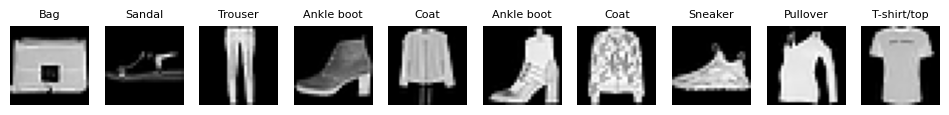

In [6]:
def show_images(loader, n: int = 10) -> None:
    x, y = next(iter(loader))
    x = x[:n]
    y = y[:n]

    plt.figure(figsize=(12, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        # Обратно денормализуем для отображения
        img = x[i].squeeze().numpy()
        img = img * 0.5 + 0.5
        plt.imshow(img, cmap="gray")
        plt.title(class_names[y[i].item()], fontsize=8)
        plt.axis("off")
    plt.show()

show_images(train_loader, n=10)

## Модель: MLP (nn.Module)

Сделаем класс, который умеет:
- Flatten (784 признака),
- несколько Linear слоёв,
- активации,
- опционально Dropout и BatchNorm.

Важно: **Dropout и BatchNorm ведут себя по-разному в train/eval режиме** –
поэтому мы обязаны в цикле обучения корректно переключать `model.train()` / `model.eval()`.

In [7]:
class MLP(nn.Module):
    def __init__(
        self,
        input_dim: int = 28 * 28,
        hidden_dims: tuple = (256, 128),
        num_classes: int = 10,
        activation: str = "relu",
        dropout_p: float = 0.0,
        use_batchnorm: bool = False,
    ):
        super().__init__()

        act = activation.lower()
        if act == "relu":
            act_layer = nn.ReLU
        elif act == "tanh":
            act_layer = nn.Tanh
        elif act == "gelu":
            act_layer = nn.GELU
        else:
            raise ValueError(f"Unknown activation: {activation}")

        layers = [nn.Flatten()]

        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act_layer())
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            prev = h

        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# Быстрый sanity-check по форме
model = MLP(dropout_p=0.2, use_batchnorm=True).to(device)
with torch.no_grad():
    out = model(x_batch.to(device))
print("logits:", out.shape)

logits: torch.Size([256, 10])


## Цикл обучения: train/eval + no_grad

В PyTorch обычно пишут две функции:
- `train_one_epoch` – обновляет веса;
- `evaluate` – считает метрики на val/test без градиентов.

Это базовый скелет, который потом расширяется (планировщики LR, клиппинг и т.д.).


In [8]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()  # включаем train-режим (Dropout/BatchNorm!)
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()  # включаем eval-режим (Dropout/BatchNorm!)
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

### EarlyStopping (ранняя остановка)

Идея простая: если качество на validation не улучшается `patience` эпох подряд –
останавливаемся и возвращаемся к лучшим весам.

Это дешёвый и очень полезный инструмент против переобучения.

In [9]:
class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score: float, model: nn.Module) -> bool:
        # score: чем больше, тем лучше (например, val_acc).
        # Возвращает True, если нужно остановиться.
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False

        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)


## Обучение: базовый MLP (baseline)

Сначала обучим самый простой вариант (без Dropout и BatchNorm) и посмотрим:
- как падает loss,
- как растёт accuracy,
- есть ли признаки переобучения (разрыв train/val).

In [10]:
def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs: int = 20,
    early_stopping=None,
    verbose: bool = True,
):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if verbose:
            print(
                f"epoch {epoch:02d}/{epochs} | "
                f"train loss={tr_loss:.4f}, acc={tr_acc:.4f} | "
                f"val loss={va_loss:.4f}, acc={va_acc:.4f}"
            )

        if early_stopping is not None:
            should_stop = early_stopping.step(va_acc, model)
            if should_stop:
                if verbose:
                    print(
                        f"EarlyStopping: остановка на эпохе {epoch}. "
                        f"Лучший val_acc={early_stopping.best_score:.4f}"
                    )
                early_stopping.restore_best(model)
                break

    return history

epoch 01/20 | train loss=0.5899, acc=0.7903 | val loss=0.4349, acc=0.8440
epoch 02/20 | train loss=0.3971, acc=0.8552 | val loss=0.3890, acc=0.8597
epoch 03/20 | train loss=0.3529, acc=0.8713 | val loss=0.3720, acc=0.8645
epoch 04/20 | train loss=0.3246, acc=0.8805 | val loss=0.3316, acc=0.8803
epoch 05/20 | train loss=0.3044, acc=0.8869 | val loss=0.3302, acc=0.8780
epoch 06/20 | train loss=0.2857, acc=0.8939 | val loss=0.3222, acc=0.8789
epoch 07/20 | train loss=0.2714, acc=0.8988 | val loss=0.3299, acc=0.8802
epoch 08/20 | train loss=0.2549, acc=0.9063 | val loss=0.3201, acc=0.8833
epoch 09/20 | train loss=0.2472, acc=0.9082 | val loss=0.3112, acc=0.8872
epoch 10/20 | train loss=0.2328, acc=0.9137 | val loss=0.3040, acc=0.8909
epoch 11/20 | train loss=0.2259, acc=0.9162 | val loss=0.2971, acc=0.8902
epoch 12/20 | train loss=0.2168, acc=0.9192 | val loss=0.3037, acc=0.8926
epoch 13/20 | train loss=0.2086, acc=0.9220 | val loss=0.3153, acc=0.8887
epoch 14/20 | train loss=0.2004, acc=0

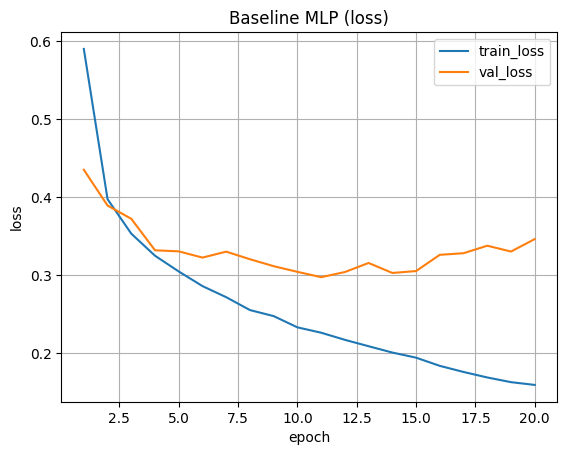

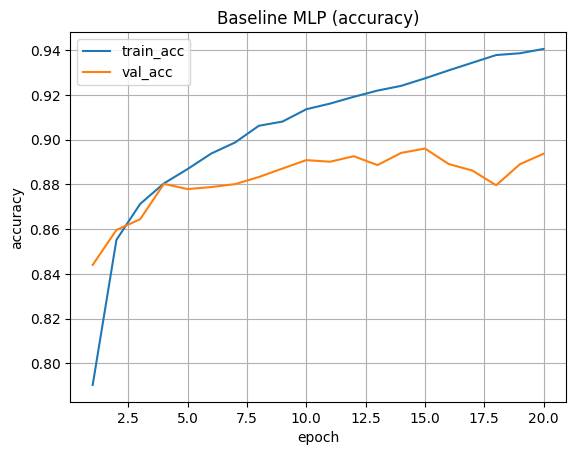

In [11]:
# Baseline: без Dropout и BatchNorm
set_seed(42)
baseline = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline.parameters(), lr=1e-3)

history_baseline = fit(
    baseline, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_baseline, title="Baseline MLP")

In [12]:
# Финальная проверка на test
test_loss, test_acc = evaluate(baseline, test_loader, criterion, device)
print(f"Baseline test: loss={test_loss:.4f}, acc={test_acc:.4f}")

Baseline test: loss=0.3887, acc=0.8824


## Эксперимент 1: Dropout

Dropout случайно зануляет часть нейронов на обучении.
Эффект:
- модель хуже запоминает шум или частности,
- часто лучше обобщает на validation.

Важно: Dropout активен только в `model.train()`; в `model.eval()` он выключен.

epoch 01/20 | train loss=0.6680, acc=0.7594 | val loss=0.4548, acc=0.8320
epoch 02/20 | train loss=0.4487, acc=0.8372 | val loss=0.3921, acc=0.8580
epoch 03/20 | train loss=0.4082, acc=0.8502 | val loss=0.3707, acc=0.8668
epoch 04/20 | train loss=0.3820, acc=0.8619 | val loss=0.3594, acc=0.8712
epoch 05/20 | train loss=0.3609, acc=0.8690 | val loss=0.3525, acc=0.8755
epoch 06/20 | train loss=0.3480, acc=0.8722 | val loss=0.3331, acc=0.8802
epoch 07/20 | train loss=0.3354, acc=0.8779 | val loss=0.3363, acc=0.8796
epoch 08/20 | train loss=0.3252, acc=0.8827 | val loss=0.3453, acc=0.8757
epoch 09/20 | train loss=0.3153, acc=0.8838 | val loss=0.3237, acc=0.8855
epoch 10/20 | train loss=0.3091, acc=0.8865 | val loss=0.3154, acc=0.8827
epoch 11/20 | train loss=0.2981, acc=0.8913 | val loss=0.3168, acc=0.8863
epoch 12/20 | train loss=0.2936, acc=0.8918 | val loss=0.3179, acc=0.8850
epoch 13/20 | train loss=0.2885, acc=0.8945 | val loss=0.3062, acc=0.8910
epoch 14/20 | train loss=0.2832, acc=0

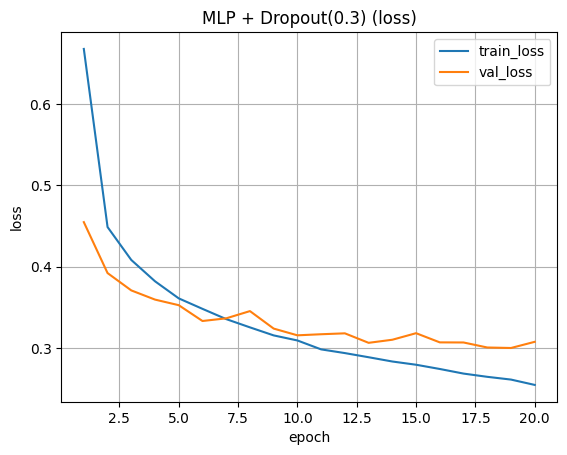

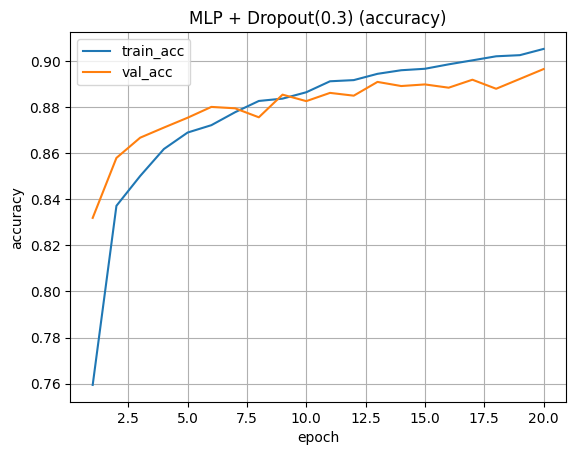

Dropout test: loss=0.3180, acc=0.8922


In [13]:
set_seed(42)
dropout_model = MLP(hidden_dims=(256, 128), dropout_p=0.3, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(dropout_model.parameters(), lr=1e-3)

history_dropout = fit(
    dropout_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_dropout, title="MLP + Dropout(0.3)")
test_loss, test_acc = evaluate(dropout_model, test_loader, criterion, device)
print(f"Dropout test: loss={test_loss:.4f}, acc={test_acc:.4f}")

## Эксперимент 2: BatchNorm

BatchNorm нормализует активации внутри сети.
Обычно даёт:
- более стабильное обучение,
- иногда выше итоговое качество,
- меньшую чувствительность к инициализации и масштабам.

Важно: BatchNorm использует разные статистики в train/eval режиме, поэтому переключение режимов критично.

epoch 01/20 | train loss=0.5008, acc=0.8335 | val loss=0.3825, acc=0.8568
epoch 02/20 | train loss=0.3296, acc=0.8794 | val loss=0.3484, acc=0.8723
epoch 03/20 | train loss=0.2897, acc=0.8933 | val loss=0.3163, acc=0.8851
epoch 04/20 | train loss=0.2636, acc=0.9023 | val loss=0.3069, acc=0.8866
epoch 05/20 | train loss=0.2419, acc=0.9105 | val loss=0.3122, acc=0.8872
epoch 06/20 | train loss=0.2233, acc=0.9172 | val loss=0.3386, acc=0.8743
epoch 07/20 | train loss=0.2068, acc=0.9230 | val loss=0.3127, acc=0.8909
epoch 08/20 | train loss=0.1933, acc=0.9271 | val loss=0.3246, acc=0.8863
epoch 09/20 | train loss=0.1775, acc=0.9344 | val loss=0.3045, acc=0.8930
epoch 10/20 | train loss=0.1682, acc=0.9374 | val loss=0.3215, acc=0.8886
epoch 11/20 | train loss=0.1579, acc=0.9417 | val loss=0.3287, acc=0.8870
epoch 12/20 | train loss=0.1457, acc=0.9463 | val loss=0.3376, acc=0.8860
epoch 13/20 | train loss=0.1381, acc=0.9488 | val loss=0.3386, acc=0.8902
epoch 14/20 | train loss=0.1249, acc=0

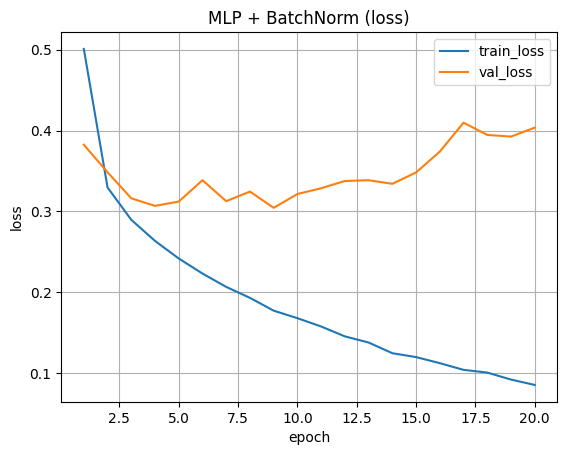

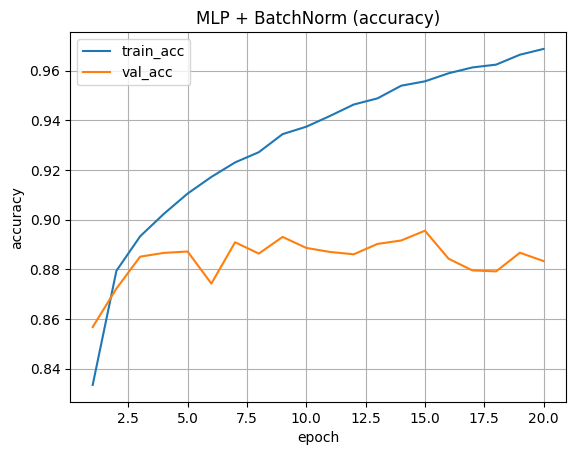

BatchNorm test: loss=0.4175, acc=0.8888


In [14]:
set_seed(42)
bn_model = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(bn_model.parameters(), lr=1e-3)

history_bn = fit(
    bn_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_bn, title="MLP + BatchNorm")
test_loss, test_acc = evaluate(bn_model, test_loader, criterion, device)
print(f"BatchNorm test: loss={test_loss:.4f}, acc={test_acc:.4f}")

## Эксперимент 3: Dropout, BatchNorm, EarlyStopping

Теперь соберём практичный вариант:
- Dropout с BatchNorm,
- и добавим EarlyStopping по val accuracy.

Идея: не тратить эпохи впустую и не уехать в переобучение.

epoch 01/50 | train loss=0.5889, acc=0.8074 | val loss=0.4025, acc=0.8532
epoch 02/50 | train loss=0.4029, acc=0.8572 | val loss=0.3633, acc=0.8678
epoch 03/50 | train loss=0.3643, acc=0.8679 | val loss=0.3453, acc=0.8753
epoch 04/50 | train loss=0.3384, acc=0.8780 | val loss=0.3281, acc=0.8776
epoch 05/50 | train loss=0.3219, acc=0.8829 | val loss=0.3247, acc=0.8842
epoch 06/50 | train loss=0.3058, acc=0.8883 | val loss=0.3132, acc=0.8834
epoch 07/50 | train loss=0.2974, acc=0.8910 | val loss=0.3311, acc=0.8792
epoch 08/50 | train loss=0.2822, acc=0.8959 | val loss=0.3112, acc=0.8872
epoch 09/50 | train loss=0.2754, acc=0.8986 | val loss=0.3044, acc=0.8918
epoch 10/50 | train loss=0.2684, acc=0.8996 | val loss=0.2927, acc=0.8927
epoch 11/50 | train loss=0.2583, acc=0.9038 | val loss=0.2927, acc=0.8962
epoch 12/50 | train loss=0.2521, acc=0.9065 | val loss=0.2990, acc=0.8907
epoch 13/50 | train loss=0.2446, acc=0.9089 | val loss=0.2981, acc=0.8939
epoch 14/50 | train loss=0.2392, acc=0

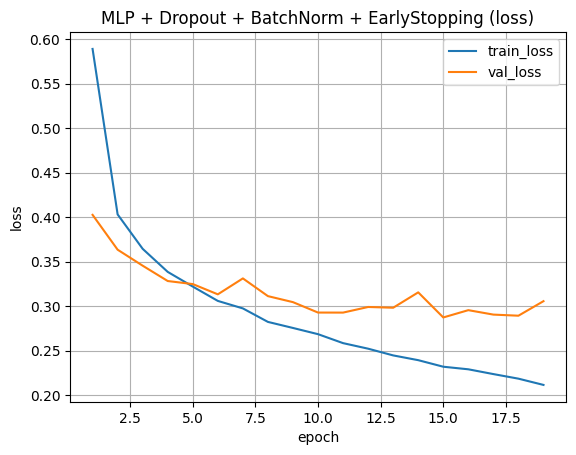

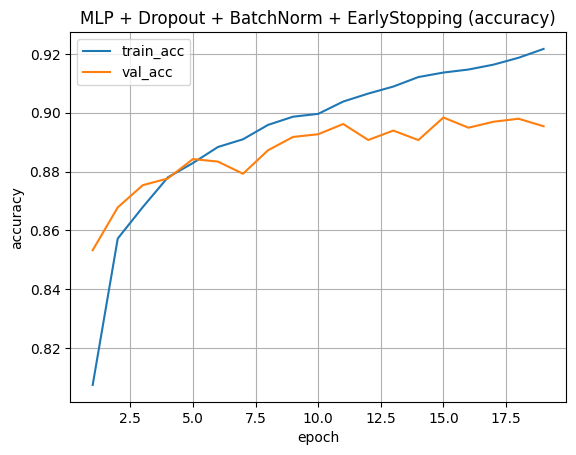

Combo test: loss=0.3019, acc=0.8907


In [15]:
set_seed(42)
combo_model = MLP(hidden_dims=(256, 128), dropout_p=0.3, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(combo_model.parameters(), lr=1e-3)

es = EarlyStopping(patience=4, min_delta=0.0005)

history_combo = fit(
    combo_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=50,  # дадим больше эпох, но остановимся рано
    early_stopping=es,
    verbose=True
)

plot_history(history_combo, title="MLP + Dropout + BatchNorm + EarlyStopping")
test_loss, test_acc = evaluate(combo_model, test_loader, criterion, device)
print(f"Combo test: loss={test_loss:.4f}, acc={test_acc:.4f}")

## Мини-сравнение результатов

Сведём итог по test accuracy (для ориентира).


In [16]:
results = {
    "baseline": evaluate(baseline, test_loader, nn.CrossEntropyLoss(), device)[1],
    "dropout": evaluate(dropout_model, test_loader, nn.CrossEntropyLoss(), device)[1],
    "batchnorm": evaluate(bn_model, test_loader, nn.CrossEntropyLoss(), device)[1],
    "combo": evaluate(combo_model, test_loader, nn.CrossEntropyLoss(), device)[1],
}

for k, v in results.items():
    print(f"{k:>9}: test_acc={v:.4f}")

 baseline: test_acc=0.8824
  dropout: test_acc=0.8922
batchnorm: test_acc=0.8888
    combo: test_acc=0.8907


## Бонус: активации и инициализация

Цель бонуса – не перебрать всё, а увидеть эффект:
- `tanh` часто обучается иначе, чем `ReLU`,
- Xavier/Kaiming по-разному подходят к разным активациям.

Сделаем небольшой эксперимент на коротком числе эпох.

In [17]:
def init_weights(module: nn.Module, init: str = "kaiming") -> None:
    # Инициализация только для Linear слоёв.
    if isinstance(module, nn.Linear):
        if init == "kaiming":
            nn.init.kaiming_normal_(module.weight, nonlinearity="relu")
        elif init == "xavier":
            nn.init.xavier_normal_(module.weight)
        else:
            raise ValueError(f"Unknown init: {init}")
        if module.bias is not None:
            nn.init.zeros_(module.bias)


def run_activation_init_experiment(activation: str, init: str, epochs: int = 8):
    set_seed(42)
    m = MLP(hidden_dims=(256, 128), activation=activation, dropout_p=0.0, use_batchnorm=False).to(device)
    m.apply(lambda mod: init_weights(mod, init=init))

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(m.parameters(), lr=1e-3)

    h = fit(
        m, train_loader, val_loader, optimizer, criterion, device,
        epochs=epochs, early_stopping=None, verbose=False
    )
    final_val = h["val_acc"][-1]
    return final_val

experiments = [
    ("relu", "kaiming"),
    ("relu", "xavier"),
    ("tanh", "xavier"),
    ("tanh", "kaiming"),
]

for act, init in experiments:
    val_acc = run_activation_init_experiment(act, init, epochs=8)
    print(f"activation={act:<4} init={init:<7} -> val_acc(last)={val_acc:.4f}")

activation=relu init=kaiming -> val_acc(last)=0.8923
activation=relu init=xavier  -> val_acc(last)=0.8865
activation=tanh init=xavier  -> val_acc(last)=0.8907
activation=tanh init=kaiming -> val_acc(last)=0.8900


## Выводы

1) PyTorch-минимум для нейросети – это: `Dataset/DataLoader`, `nn.Module`, `loss`, `optimizer`, правильные режимы `train/eval`.
2) Переобучение видно по разрыву train/val и росту val loss при падении train loss.
3) Dropout, BatchNorm, EarlyStopping – это практичные базовые инструменты, которые часто дают выигрыш.
4) Активации и инициализация реально влияют на динамику обучения (поэтому важно понимать, что вы включаете в модель).